# mapping

### qasmbench-large

| source_file   | swap_count | final_depth |
|---------------|-----------:|------------:|
| qpilot.csv    | 492.454545 | 910.818182  |
| cirq.csv      | 750.045455 | 1153.318182 |
| qmap.csv      | 507.409091 | 925.818182  |
| pytket.csv    | 587.954545 | 1028.772727 |
| eoh.csv       | 519.954545 | 897.681818  |
| funsearch.csv | 521.818182 | 917.681818  |
| Reevo.csv     | 498.363636 | 922.181818  |
| Randsample.csv| 510.818182 | 913.318182  |
| mcts-ahd.csv  | 521.545455 | 921.636364  |
| hill_climb.csv| 590.545455 | 996.500000  |
| sabre.csv     | 577.772727 | 1066.909091 |
| partevo.csv   | 525.636364 | 935.727273  |


--

| Method         | Swap Improvement (%) | Depth Improvement (%) |
|----------------|--------------------|----------------------|
| cirq           | 34.34%             | 21.03%               |
| qmap           | 2.95%              | 1.62%                |
| pytket         | 16.25%             | 11.47%               |
| eoh            | 5.29%              | -1.46%               |
| funsearch      | 5.63%              | 0.75%                |
| Reevo          | 1.19%              | 1.23%                |
| Randsample     | 3.60%              | 0.27%                |
| mcts-ahd       | 5.58%              | 1.17%                |
| hill_climb     | 16.61%             | 8.60%                |
| sabre          | 14.77%             | 14.63%               |
| partevo        | 6.32%              | 2.66%                |

### queko 16qbt

In [20]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-16qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file  swap_count  final_depth
0       qpilot.csv  586.155556   975.155556
1         cirq.csv  824.711111  1150.033333
2         qmap.csv  845.011111  1293.944444
3       pytket.csv  774.811111  1179.688889
4          eoh.csv  795.444444  1137.533333
5    funsearch.csv  793.777778  1314.900000
6        Reevo.csv  617.166667  1076.633333
7   Randsample.csv  622.333333  1063.833333
8     mcts-ahd.csv  747.844444  1265.511111
9   hill_climb.csv  780.888889  1327.255556
10       sabre.csv  604.111111   981.522222
11     partevo.csv  686.677778  1174.700000


In [21]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-16qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-16qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 28.93                  15.21
      qmap                 30.63                  24.64
    pytket                 24.35                  17.34
       eoh                 26.31                  14.27
 funsearch                 26.16                  25.84
     Reevo                  5.02                   9.43
Randsample                  5.81                   8.34
  mcts-ahd                 21.62                  22.94
hill_climb                 24.94                  26.53
     sabre                  2.97                   0.65
   partevo                 14.64                  16.99
Average Swap Improvement:  19.22%
Average Depth Improvement: 16.56%


### queko 54qbt

In [22]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-54qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)

Error processing pytket.csv: Could not convert ['1269798327203155501141512305540713245144701728114044309840716091646316015110805032147119126181881151162814498timeout7636130786814160181113788031161724336631127926625118885355102064326926279907469233522204205123624636928613888145497169130461383724121300210276timeout1539113145489873112193timeout501621334173208260285481383113048741814376122984701139982379646689014417839111208111107845361567675508435515621'
 '78665932401991966862754433417993860792272472366534394613604967066333009863656001114470168978528timeout44697729414094566576518469571331402476784335676730596090231051604777445413571249254773902673526484468590412477758534122177855985timeout91497327299042251163timeout30561171244711363519303521177846447986457484252385161239397255942556485767246684490421973771342324479122'] to numeric

Preview of the data:
       source_file    swap_count  final_depth
0       qpilot.csv   5670.277778  2745.900000
1         cirq.csv  10111.922222  4565.433333


In [23]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-54qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-54qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Error processing pytket.csv: Could not convert string '1269798327203155501141512305540713245144701728114044309840716091646316015110805032147119126181881151162814498timeout7636130786814160181113788031161724336631127926625118885355102064326926279907469233522204205123624636928613888145497169130461383724121300210276timeout1539113145489873112193timeout501621334173208260285481383113048741814376122984701139982379646689014417839111208111107845361567675508435515621' to numeric
    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 43.92                  39.85
      qmap                 54.37                  21.46
       eoh                  9.96                   6.80
 funsearch                  8.50                   6.83
     Reevo                 -3.93                  -3.43
Randsample                 -0.81                  -1.36
  mcts-ahd                  7.05                   4.97
hill_climb                 10.25                   8.31
     sabre             

### queko 81qbt

In [24]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-81qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            # Convert columns to numeric and force errors to NaN
            df[columns_to_mean] = df[columns_to_mean].apply(
                pd.to_numeric, errors='coerce'
            )

            means = df[columns_to_mean].mean(skipna=True).to_dict()
            means['source_file'] = file_name
            summary_data.append(means)

        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]

print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file    swap_count  final_depth
0       qpilot.csv  12347.500000  3652.200000
1         cirq.csv  18258.522222  5244.800000
2         qmap.csv  25539.500000  4818.633333
3       pytket.csv  18443.306818  7544.625000
4          eoh.csv  13889.877778  4034.800000
5    funsearch.csv  13403.833333  3924.344444
6        Reevo.csv  11831.377778  3519.511111
7   Randsample.csv  12177.377778  3589.288889
8     mcts-ahd.csv  13260.422222  3893.244444
9   hill_climb.csv  13632.055556  3965.888889
10       sabre.csv  14463.044444  4984.077778
11     partevo.csv  12981.766667  3776.044444


In [25]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-81qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-81qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Error processing pytket.csv: Could not convert string '29066timeout27231730922303326681784420047448614028193691568220852274601337411867484212699275224552442626337364233088699651748212071timeout31953307217914949024397433335409149522654786681351825822389821403197724230105161396330693142758121205002647021066111421845115525916431438260271218532558390179977677144832891219298300321214122726532226519424823787166006831185012950424885245641947313337245622830715135141112095827640298381679529015' to numeric
    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 32.37                  30.37
      qmap                 51.65                  24.21
       eoh                 11.10                   9.48
 funsearch                  7.88                   6.93
     Reevo                 -4.36                  -3.77
Randsample                 -1.40                  -1.75
  mcts-ahd                  6.88                   6.19
hill_climb                  9.42                  

### plots queko-16qbt

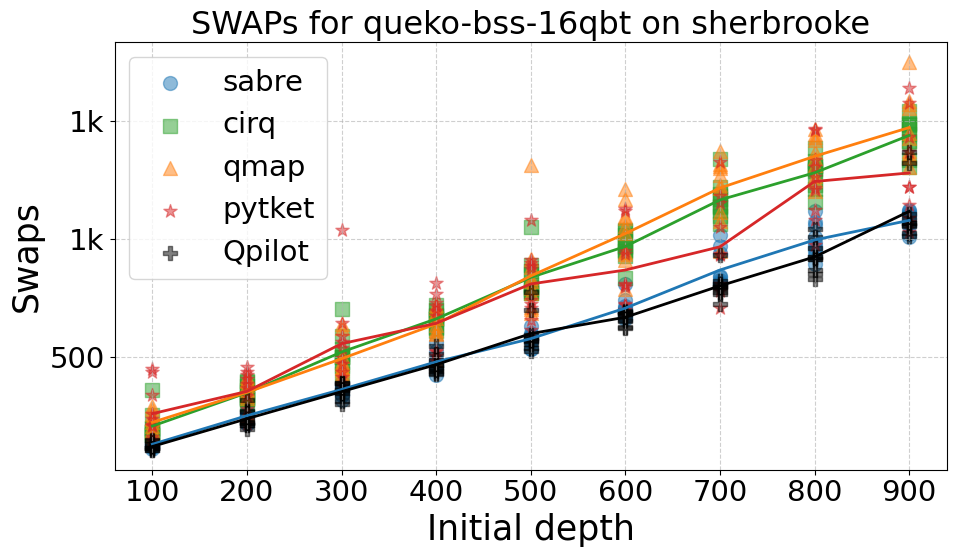

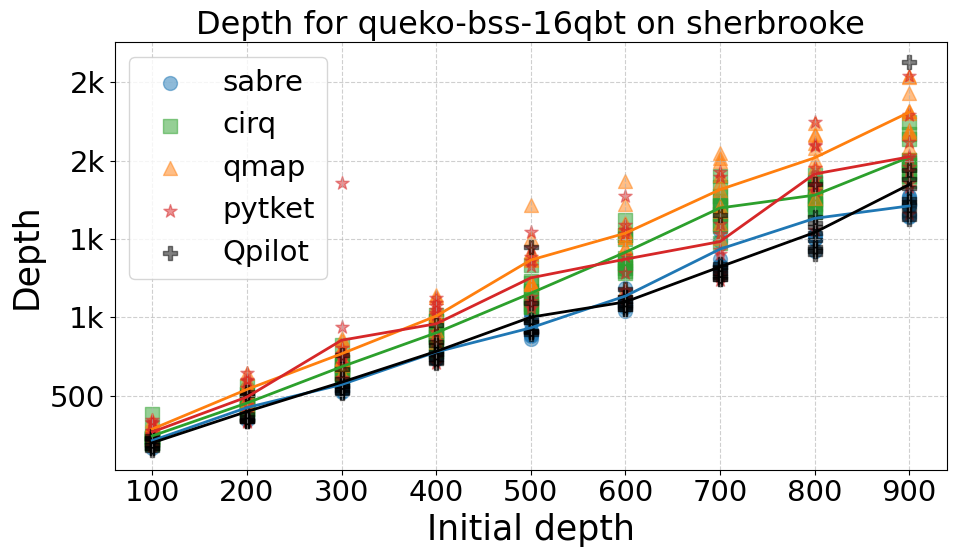

In [3]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

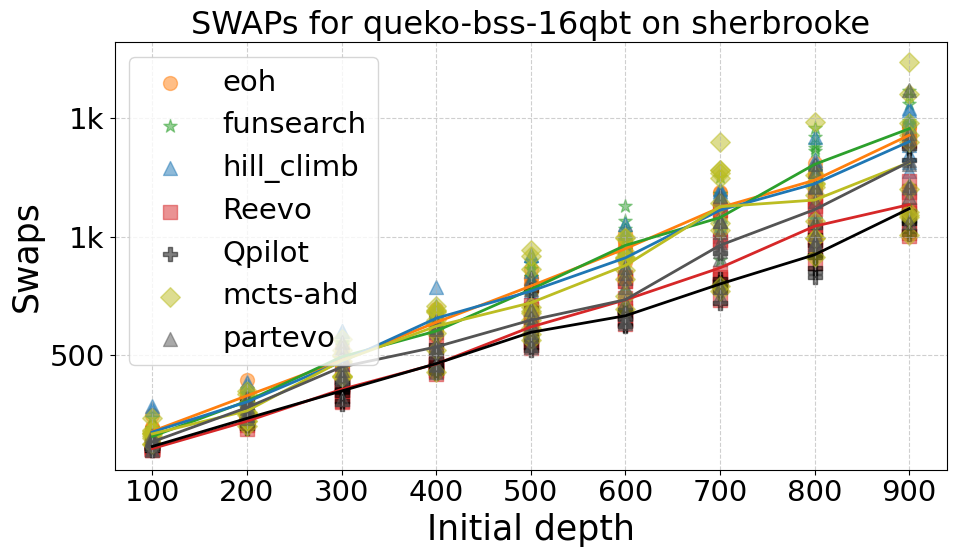

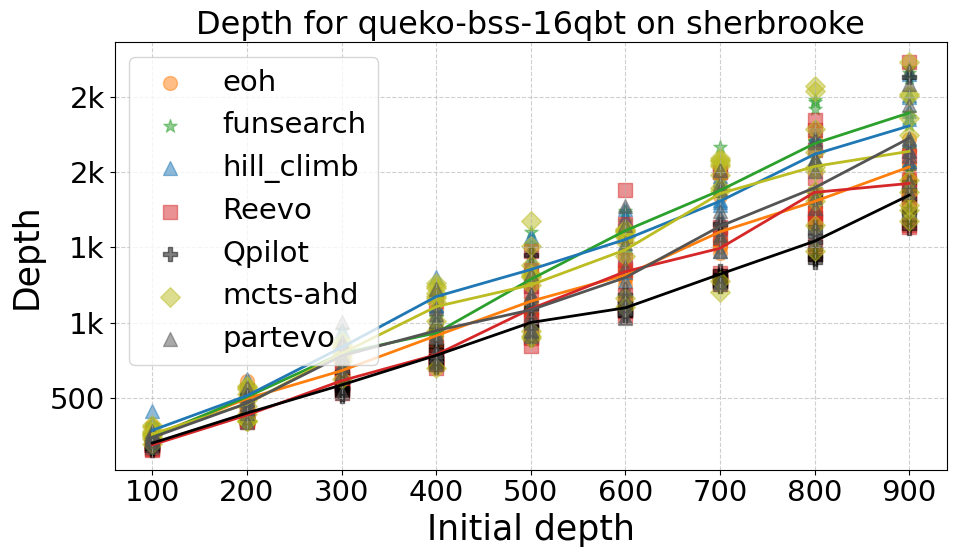

In [4]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/funsearch.csv",
    "hill_climb": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/hill_climb.csv",
    "Reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/Reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/mcts-ahd.csv",
    "partevo" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/partevo.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

## Benchmark Results: queko16qbt

### Raw Performance Metrics
| Source File      | Swap Count | Final Depth |
| :--------------- | :--------- | :---------- |
| `qpilot.csv`     | 586.155556 | 975.155556  |
| `cirq.csv`       | 824.711111 | 1150.033333 |
| `qmap.csv`       | 845.011111 | 1293.944444 |
| `pytket.csv`     | 774.811111 | 1179.688889 |
| `eoh.csv`        | 795.444444 | 1137.533333 |
| `funsearch.csv`  | 793.777778 | 1314.900000 |
| `Reevo.csv`      | 617.166667 | 1076.633333 |
| `mcts-ahd.csv`   | 747.844444 | 1265.511111 |
| `hill_climb.csv` | 780.888889 | 1327.255556 |
| `sabre.csv`      | 604.111111 | 981.522222  |
| `partevo.csv`    | 686.677778 | 1174.700000 |


### Improvement Percentages
| Method         | Swap Improvement (%) | Depth Improvement (%) |
| :------------- | :------------------- | :-------------------- |
| **cirq**       | 28.93                | 15.21                 |
| **qmap**       | 30.63                | 24.64                 |
| **pytket**     | 24.35                | 17.34                 |
| **eoh**        | 26.31                | 14.27                 |
| **funsearch**  | 26.16                | 25.84                 |
| **Reevo**      | 5.02                 | 9.43                  |
| **mcts-ahd**   | 21.62                | 22.94                 |
| **hill_climb** | 24.94                | 26.53                 |
| **sabre**      | 2.97                 | 0.65                  |
| **partevo**    | 14.64                | 16.99                 |






### plots queko-54qbt

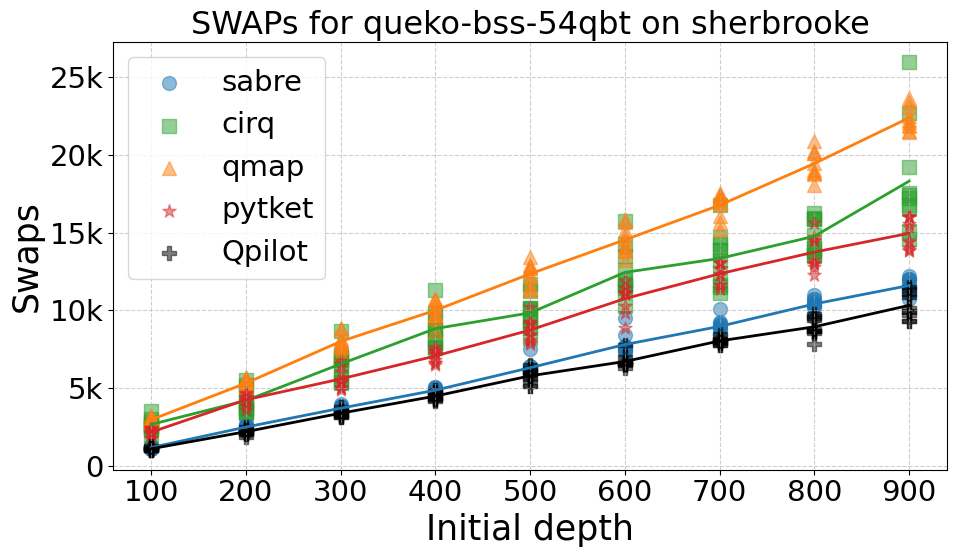

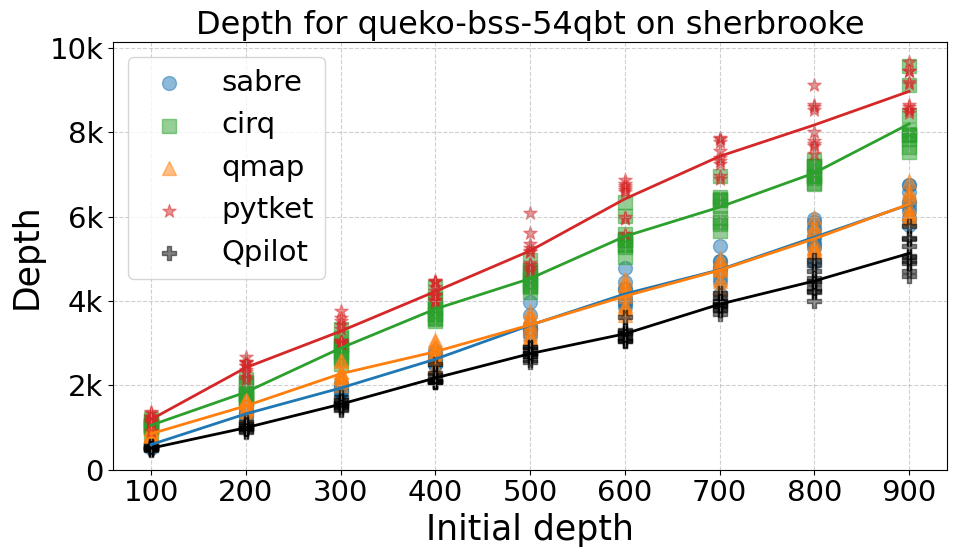

In [28]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

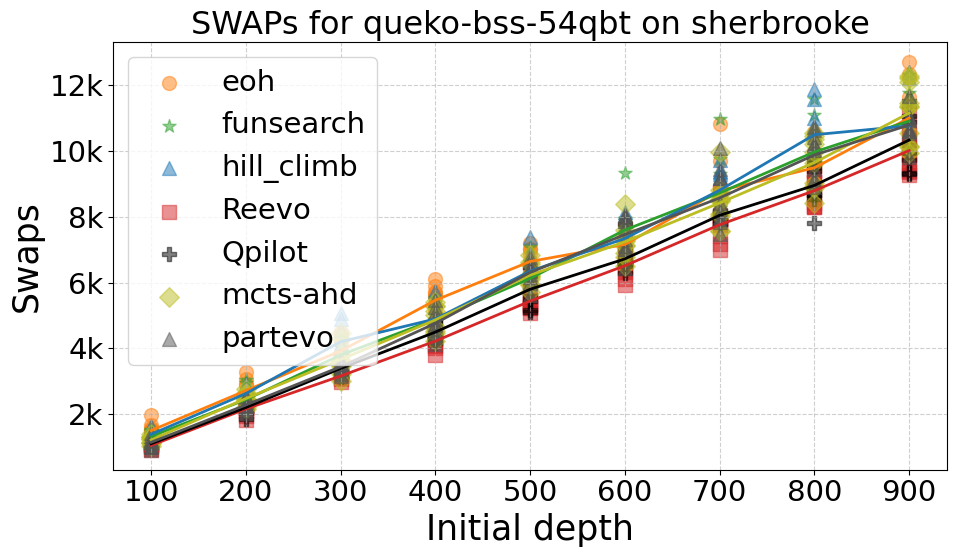

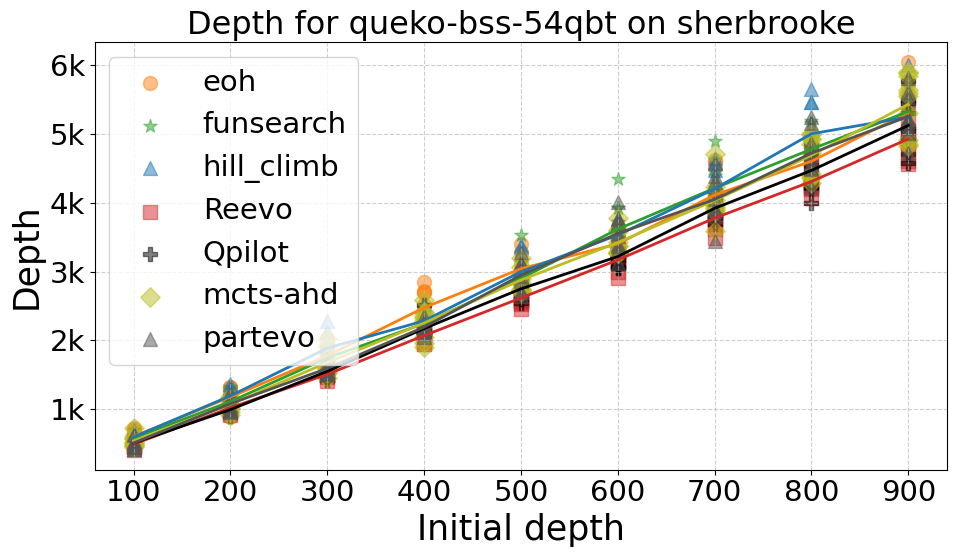

In [5]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/funsearch.csv",
    "hill_climb": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/hill_climb.csv",
    "Reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/Reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/mcts-ahd.csv",
    "partevo" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/partevo.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

## Benchmark Results: queko54qbt

### Raw Performance Metrics
| Source File      | Swap Count   | Final Depth |
| :--------------- | :----------- | :---------- |
| `qpilot.csv`     | 5670.277778  | 2745.900000 |
| `cirq.csv`       | 10111.922222 | 4565.433333 |
| `qmap.csv`       | 12426.188889 | 3496.344444 |
| `eoh.csv`        | 6297.288889  | 2946.222222 |
| `funsearch.csv`  | 6197.055556  | 2947.111111 |
| `Reevo.csv`      | 5455.766667  | 2654.955556 |
| `mcts-ahd.csv`   | 6100.411111  | 2889.400000 |
| `hill_climb.csv` | 6317.877778  | 2994.611111 |
| `sabre.csv`      | 6378.322222  | 3398.655556 |
| `partevo.csv`    | 6070.411111  | 2878.488889 |


### Improvement Percentages
| Method         | Swap Improvement (%) | Depth Improvement (%) |
| :------------- | :------------------- | :-------------------- |
| **cirq**       | 43.92                | 39.85                 |
| **qmap**       | 54.37                | 21.46                 |
| **eoh**        | 9.96                 | 6.80                  |
| **funsearch**  | 8.50                 | 6.83                  |
| **Reevo**      | -3.93                | -3.43                 |
| **mcts-ahd**   | 7.05                 | 4.97                  |
| **hill_climb** | 10.25                | 8.31                  |
| **sabre**      | 11.10                | 19.21                 |
| **partevo**    | 6.59                 | 4.61                  |


### plots queko-81qbt

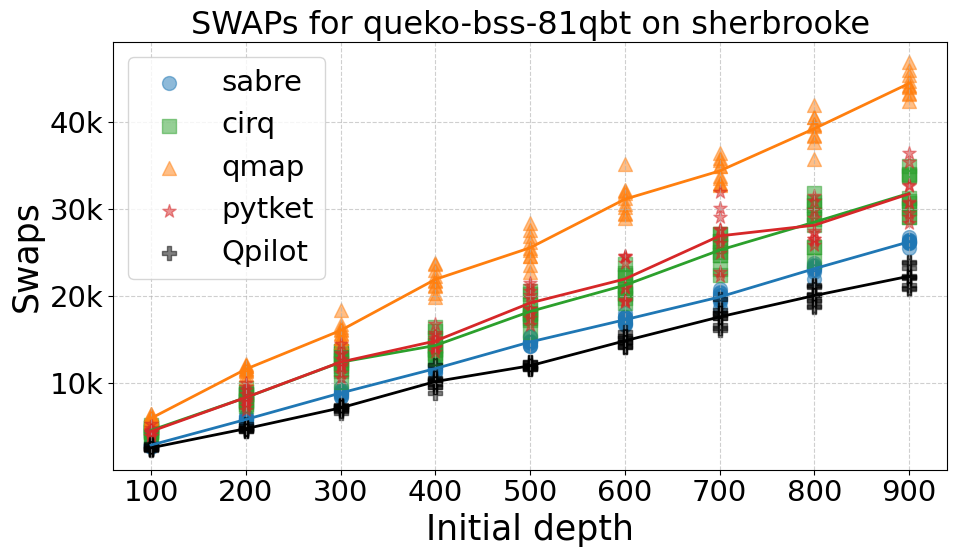

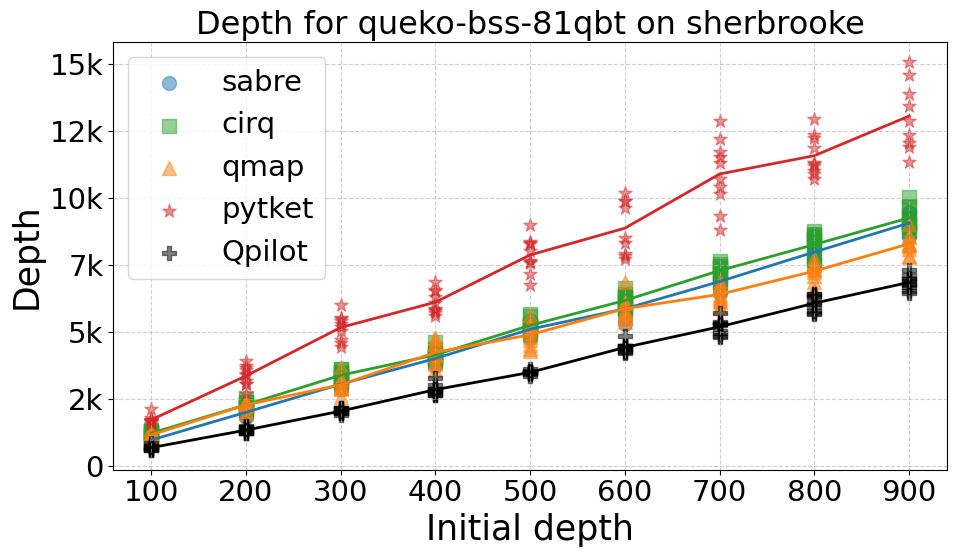

In [9]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

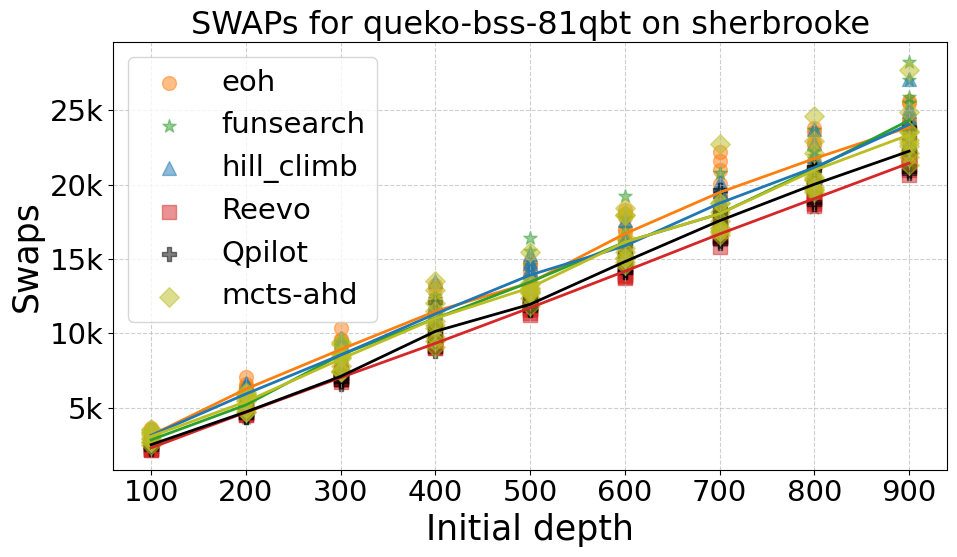

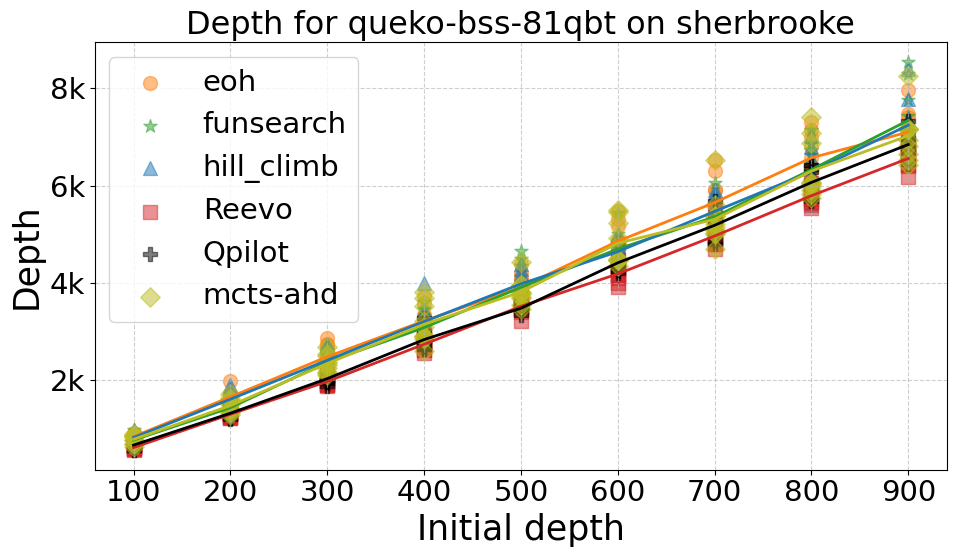

In [30]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/funsearch.csv",
    "hill_climb": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/hill_climb.csv",
    "Reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/Reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/mcts-ahd.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

## Benchmark Results: queko81qbt

### Raw Performance Metrics
| Source File      | Swap Count   | Final Depth |
| :--------------- | :----------- | :---------- |
| `qpilot.csv`     | 12347.500000 | 3652.200000 |
| `cirq.csv`       | 18258.522222 | 5244.800000 |
| `qmap.csv`       | 25539.500000 | 4818.633333 |
| `pytket.csv`     | 18443.306818 | 7544.625000 |
| `eoh.csv`        | 13889.877778 | 4034.800000 |
| `funsearch.csv`  | 13403.833333 | 3924.344444 |
| `Reevo.csv`      | 11831.377778 | 3519.511111 |
| `mcts-ahd.csv`   | 13260.422222 | 3893.244444 |
| `hill_climb.csv` | 13632.055556 | 3965.888889 |
| `sabre.csv`      | 14463.044444 | 4984.077778 |
| `partevo.csv`    | 12981.766667 | 3776.044444 |



### Improvement Percentages
| Method         | Swap Improvement (%) | Depth Improvement (%) |
| :------------- | :------------------- | :-------------------- |
| **cirq**       | 32.37                | 30.37                 |
| **qmap**       | 51.65                | 24.21                 |
| **eoh**        | 11.10                | 9.48                  |
| **funsearch**  | 7.88                 | 6.93                  |
| **Reevo**      | -4.36                | -3.77                 |
| **mcts-ahd**   | 6.88                 | 6.19                  |
| **hill_climb** | 9.42                 | 7.91                  |
| **sabre**      | 14.63                | 26.72                 |
| **partevo**    | 4.89                 | 3.28                  |
